### **Энтропийный оптимальный транспорт: анализ двойственности и методы оптимизации**

Мы решаем энропийно-регуляризованную задачу оптимального транпоспорта. Согласно теоретическому анализу, переход к двойственной задаче позлоляет использовать некоторые методы первого и второго порядков. 



Мы сравним подходы:

1\) **Классический градиентный спуск**

2\) **Ускоренный градиентный спуск** (в его стандартном виде)

3\) **Primal-Dual подход** (ускоренный метод с усреднением транспортного плана)

4\) **Кубический метод Ньютона**


*Параметры, формулы и обозначения соответствуют представленному PDF-отчету.*

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize
import numpy as np
from numpy.linalg import solve, norm
import matplotlib.pyplot as plt

# Настройки для графиков академического стиля
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 14,
    "axes.grid": True,
    "grid.alpha": 0.5,
    "grid.linestyle": "--",
    "lines.linewidth": 2.5,
    "figure.figsize": (12, 7)
})

Для тестирования сгенерируем одномерную задачу оптимального транспорта. Источники $O$ и потребители $D$ задаются в виде гауссовских распределений на отрезке $[0, 1]$. Матрица стоимостей $c$ формируется как квадрат расстояния между точками.

In [7]:
def create_task(n=50, m=50):
    """Генерация 1D задачи оптимального транспорта."""
    coords_O, coords_D = np.linspace(0, 1, n), np.linspace(0, 1, m)
    
    O = np.exp(-((coords_O - 0.3) ** 2) / 0.05)
    D = np.exp(-((coords_D - 0.7) ** 2) / 0.05)
    
    b = np.concatenate([O / np.sum(O), D / np.sum(D)])
    
    c = np.zeros(n * m)
    for i in range(n):
        for j in range(m):
            c[i * m + j] = (coords_O[i] - coords_D[j]) ** 2 
            
    A = np.zeros((n + m, n * m))
    for i in range(n):
        for j in range(m):
            A[i, i * m + j] = 1         
            A[n + j, i * m + j] = 1     
            
    return b, c, A

def get_x_softmax(y, c, A, gamma):
    """Восстановление прямого плана x по двойственным переменным y."""
    power = -(c + A.T @ y) / gamma
    power -= np.max(power) # Вычитаем максимум для стабильности экспоненты
    x = np.exp(power)
    return x / np.sum(x)

def residual(x, b, A):
    """Вычисление нормы невязки ограничений ||Ax - b||."""
    return np.linalg.norm(b - A @ x)

def get_hessian(y, c, A, gamma):
    """Матрица Гессе двойственной функции."""
    x = get_x_softmax(y, c, A, gamma)
    diag_x = np.diag(x)
    xxT = np.outer(x, x)
    return (1 / gamma) * A @ (diag_x - xxT) @ A.T

Реализуем нужные нам алгоритмы

In [34]:
def run_gd(b, c, A, gamma, iters):
    """Обычный градиентный спуск."""
    y = np.zeros(len(b))
    history = []
    for _ in range(iters):
        x = get_x_softmax(y, c, A, gamma)
        history.append(residual(x, b, A))
        y = y - gamma * (b - A @ x) 
    return history

def run_nest(b, c, A, gamma, iters):
    """Ускоренный метод Нестерова (без усреднения)."""
    y, y_prev = np.zeros(len(b)), np.zeros(len(b))
    history = []
    for k in range(1, iters + 1):
        v = y + ((k - 1) / (k + 2)) * (y - y_prev) 
        x = get_x_softmax(v, c, A, gamma)
        history.append(residual(x, b, A))
        y_prev, y = y, v - gamma * (b - A @ x)
    return history

def run_pd(b, c, A, gamma, iters):
    """Primal-Dual метод (с усреднением транспортного плана)."""
    y, y_prev = np.zeros(len(b)), np.zeros(len(b))
    sum_alpha_x = np.zeros(len(c))
    sum_alpha = 0.0
    history = []
    for k in range(1, iters + 1):
        v = y + ((k - 1) / (k + 2)) * (y - y_prev)
        x_v = get_x_softmax(v, c, A, gamma)
        
        # Усреднение плана
        sum_alpha_x += k * x_v
        sum_alpha += k
        x_hat = sum_alpha_x / sum_alpha
        
        history.append(residual(x_hat, b, A))
        y_prev, y = y, v - gamma * (b - A @ x_v)
    return history

def solve_cubic_subproblem_robust(H, g, M):
    """
    Надежное решение кубической подзадачи с помощью встроенного метода Брента.
    Ищет корень уравнения: (M/2) * || (H + lam*I)^(-1) g || - lam = 0
    """
    n = len(g)
    I = np.eye(n)
    
    if np.linalg.norm(g) < 1e-12:
        return np.zeros(n)

    def residual_lambda(lam):
        # Решаем СЛАУ для текущего lam
        h = np.linalg.solve(H + lam * I, -g)
        return (M / 2.0) * np.linalg.norm(h) - lam

    # Ищем правую границу, где функция гарантированно отрицательна
    lam_upper = 1.0
    while residual_lambda(lam_upper) > 0:
        lam_upper *= 2.0
        # Защита от бесконечного цикла при аномалиях
        if lam_upper > 1e10: 
            break

    # Находим точный корень методом Брента
    try:
        lam_opt = scipy.optimize.brentq(residual_lambda, 1e-10, lam_upper)
    except ValueError:
        lam_opt = lam_upper # fallback

    h_opt = np.linalg.solve(H + lam_opt * I, -g)
    return h_opt

def run_cubic_newton(b, c, A, gamma, M, iters):
    y = np.zeros(len(b))
    history = []
    
    for _ in range(iters):
        x = get_x_softmax(y, c, A, gamma)
        g = b - A @ x
        history.append(np.linalg.norm(g))
        
        if history[-1] < 1e-10:
            break
            
        H = get_hessian(y, c, A, gamma)
        h = solve_cubic_subproblem_robust(H, g, M)
        y = y + h
        
    return history

Зафиксируем значение параметра регуляризации $\gamma$ и посмотрим, как быстро падает норма невязки $\|Ax - b\|$ для каждого из методов.

<>:22: SyntaxWarning: invalid escape sequence '\e'
<>:22: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_9101/461005942.py:22: SyntaxWarning: invalid escape sequence '\e'
  ax.axhline(y=gamma_val, color='black', linestyle=':', label=f'Цель $\epsilon = {gamma_val}$')


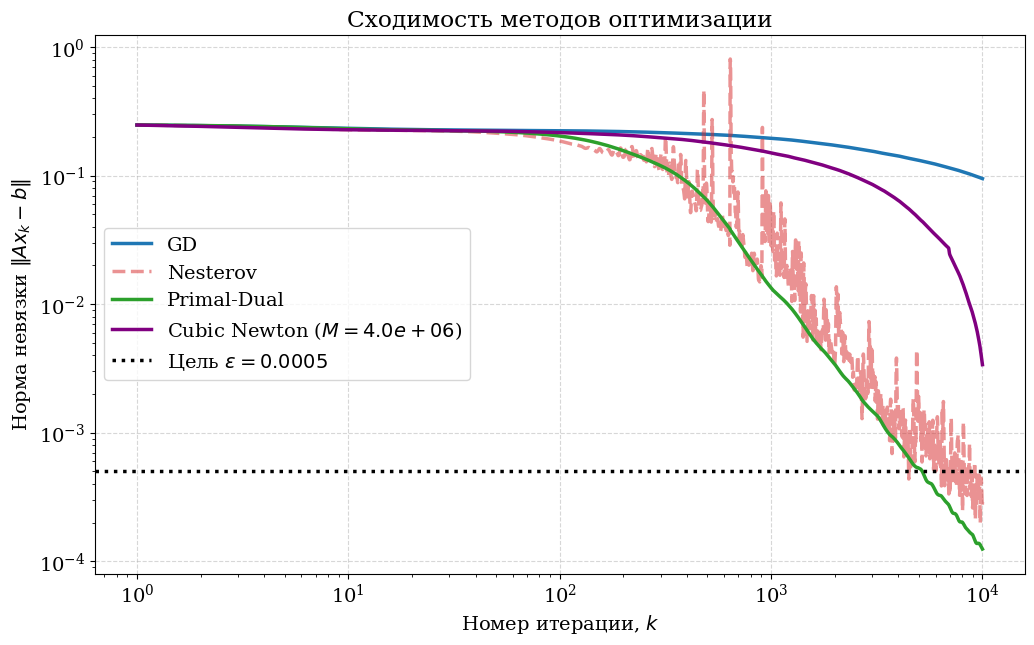

In [61]:
n_dim, m_dim = 30, 30
b, c, A = create_task(n_dim, m_dim)

gamma_val = 0.0005
iters = 10000     

# Константа M для кубического Ньютона
M_theory = 1.0 / (gamma_val ** 2)

h_gd = run_gd(b, c, A, gamma_val, iters)
h_nest = run_nest(b, c, A, gamma_val, iters)
h_pd = run_pd(b, c, A, gamma_val, iters)
h_newton = run_cubic_newton(b, c, A, gamma_val,M_theory, iters)

fig, ax = plt.subplots()

ax.plot(np.arange(1, len(h_gd) + 1), h_gd, label='GD', color='#1f77b4')
ax.plot(np.arange(1, len(h_nest) + 1), h_nest, label='Nesterov', color='#d62728', alpha=0.5, linestyle='--')
ax.plot(np.arange(1, len(h_pd) + 1), h_pd, label='Primal-Dual', color='#2ca02c')
ax.plot(np.arange(1, len(h_newton) + 1), h_newton, label=f'Cubic Newton ($M={M_theory:.1e}$)', color='purple')

ax.axhline(y=gamma_val, color='black', linestyle=':', label=f'Цель $\epsilon = {gamma_val}$')

ax.set_yscale('log')
ax.set_xscale('log')
ax.set_xlabel('Номер итерации, $k$')
ax.set_ylabel(r'Норма невязки $\|Ax_k - b\|$')
ax.set_title('Сходимость методов оптимизации')
ax.legend()
plt.show()

Запустим алгоритмы для сетки значений $\epsilon$ и зафиксируем итерацию, на которой достигается требуемая точность, чтобы сравнить наклон эмпирических графиков с теоретическими прямыми. Работать будем с обычным градиентным спуском и ускоренным градиентным спуском с усреднением

In [63]:
def find_iters_gd(b, c, A, eps, max_iters=200000):
    gamma = eps # ВАЖНО: Гамма пропорциональна эпсилон
    y = np.zeros(len(b))
    for k in range(1, max_iters + 1):
        x = get_x_softmax(y, c, A, gamma)
        res = residual(x, b, A)
        if res < eps:
            return k
        y = y - gamma * (b - A @ x)
    return max_iters

def find_iters_pd(b, c, A, eps, max_iters=100000):
    gamma = eps # ВАЖНО: Гамма пропорциональна эпсилон
    y, y_prev = np.zeros(len(b)), np.zeros(len(b))
    sum_alpha_x = np.zeros(len(c))
    sum_alpha = 0.0
    for k in range(1, max_iters + 1):
        v = y + ((k - 1) / (k + 2)) * (y - y_prev)
        x_v = get_x_softmax(v, c, A, gamma)
        sum_alpha_x += k * x_v
        sum_alpha += k
        x_hat = sum_alpha_x / sum_alpha
        
        if residual(x_hat, b, A) < eps:
            return k
        
        y_prev, y = y, v - gamma * (b - A @ x_v)
    return max_iters

Считаем Primal-Dual...
eps = 0.1000 -> 26 итераций
eps = 0.0599 -> 48 итераций
eps = 0.0359 -> 80 итераций
eps = 0.0215 -> 126 итераций
eps = 0.0129 -> 204 итераций
eps = 0.0077 -> 338 итераций
eps = 0.0046 -> 552 итераций
eps = 0.0028 -> 909 итераций
eps = 0.0017 -> 1524 итераций
eps = 0.0010 -> 2556 итераций


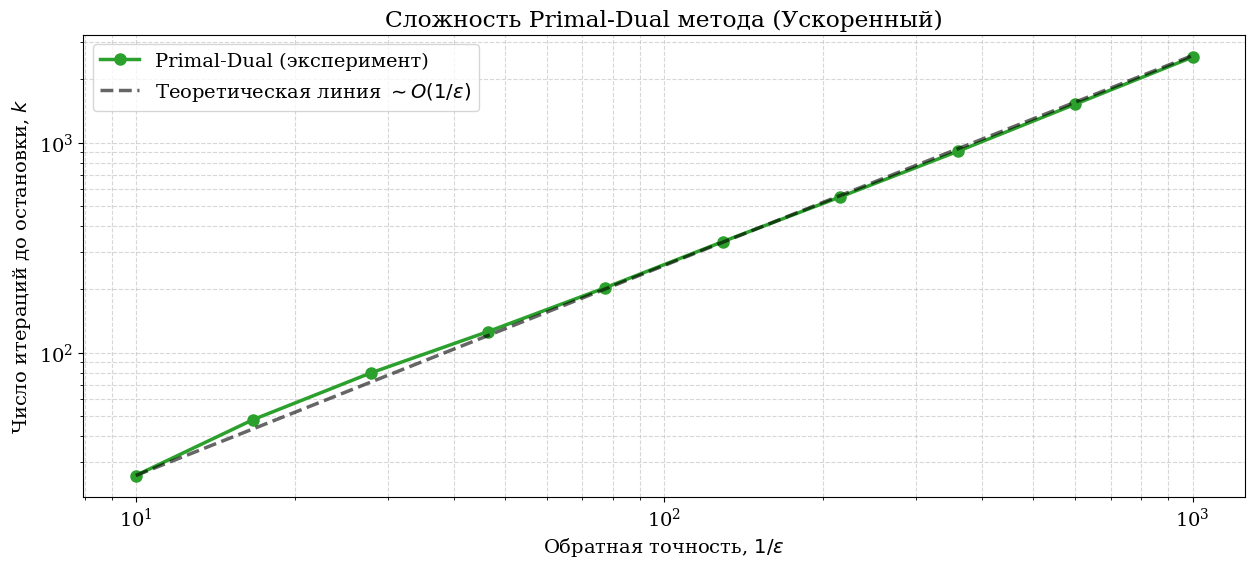

In [67]:
epsilons_pd = np.geomspace(0.1, 0.001, 10)
inv_eps_pd = 1.0 / epsilons_pd

iters_pd = []
print("Считаем Primal-Dual...")
for e in epsilons_pd:
    iters = find_iters_pd(b, c, A, e)
    iters_pd.append(iters)
    print(f"eps = {e:.4f} -> {iters} итераций")

plt.figure(figsize=(15, 6))
plt.plot(inv_eps_pd, iters_pd, 'o-', color='#2ca02c', markersize=8, label='Primal-Dual (эксперимент)')

# Рисуем референсную прямую (O(1/eps))
ref_y = inv_eps_pd * (iters_pd[0] / inv_eps_pd[0]) 
plt.plot(inv_eps_pd, ref_y, '--', color='black', alpha=0.6, label=r'Теоретическая линия $\sim O(1/\varepsilon)$')

plt.xscale('log')
plt.yscale('log')
plt.grid(True, which="both", linestyle="--", alpha=0.5)

plt.xlabel(r'Обратная точность, $1/\varepsilon$')
plt.ylabel(r'Число итераций до остановки, $k$')
plt.title('Сложность Primal-Dual метода (Ускоренный)')
plt.legend()
plt.show()

Считаем классический GD (может занять 10-20 секунд)...
eps = 0.3000 -> 1 итераций
eps = 0.1592 -> 19 итераций
eps = 0.0845 -> 86 итераций
eps = 0.0448 -> 298 итераций
eps = 0.0238 -> 878 итераций
eps = 0.0126 -> 2176 итераций
eps = 0.0067 -> 5104 итераций
eps = 0.0036 -> 11465 итераций
eps = 0.0019 -> 24552 итераций
eps = 0.0010 -> 51178 итераций


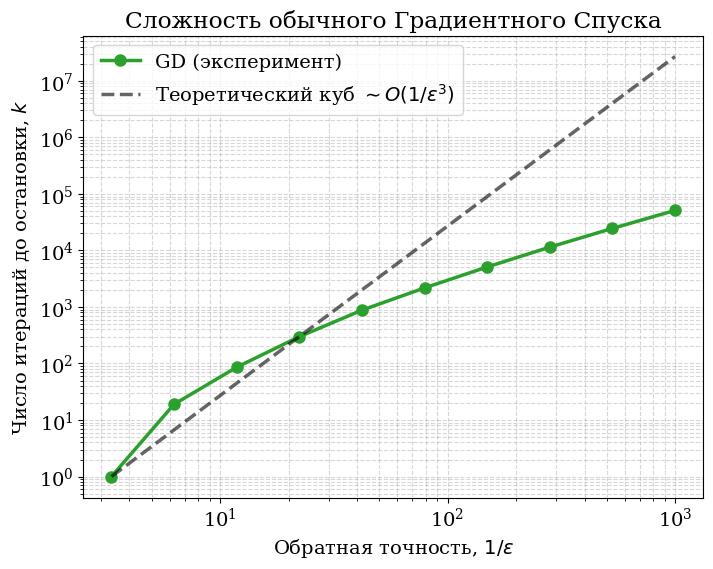

In [69]:
epsilons_gd = np.geomspace(0.3, 0.001, 10)
inv_eps_gd = 1.0 / epsilons_gd

iters_gd = []
print("Считаем классический GD (может занять 10-20 секунд)...")
for e in epsilons_gd:
    iters = find_iters_gd(b, c, A, e)
    iters_gd.append(iters)
    print(f"eps = {e:.4f} -> {iters} итераций")

plt.figure(figsize=(8, 6))
# Заменен цвет на #2ca02c и маркер на 'o'
plt.plot(inv_eps_gd, iters_gd, 'o-', color='#2ca02c', markersize=8, label='GD (эксперимент)')

# Рисуем референсную кривую O(1/eps^3)
ref_y_cube = (inv_eps_gd ** 3) * (iters_gd[0] / (inv_eps_gd[0]**3))
plt.plot(inv_eps_gd, ref_y_cube, '--', color='black', alpha=0.6, label=r'Теоретический куб $\sim O(1/\varepsilon^3)$')

plt.xscale('log')
plt.yscale('log')
plt.grid(True, which="both", linestyle="--", alpha=0.5)

plt.xlabel(r'Обратная точность, $1/\varepsilon$')
plt.ylabel(r'Число итераций до остановки, $k$')
plt.title('Сложность обычного Градиентного Спуска')
plt.legend()
plt.show()